In [8]:
import pandas as pd
import matplotlib.pyplot as plt

csv_file = "nli_result.csv"

# No header: first column is the series label, remaining columns are values
df = pd.read_csv(csv_file, header=None)

# Split labels and numeric values
labels = df.iloc[:, 0]
values = df.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

# Average rows that have the same first-column label
avg_df = values.groupby(labels).mean()

avg_df

,1,2,3,4,5,6,7
0,,,,,,,
1-gram-perf.py,0.461803,0.679322,0.767137,0.843904,0.882060,0.914607,0.921236
1-gram-perf.py2,0.522162,0.638072,0.759478,0.874343,0.893792,0.910721,0.910509
epoch-2-nli.py,0.567977,0.672733,0.835208,0.846504,0.918835,0.927993,0.927790
epoch-2-nli.py2,0.537698,0.669205,0.806760,0.863444,0.886356,0.899774,0.923969


In [9]:
avg_df = avg_df.drop('epoch-2-nli.py')
avg_df

,1,2,3,4,5,6,7
0,,,,,,,
1-gram-perf.py,0.461803,0.679322,0.767137,0.843904,0.882060,0.914607,0.921236
1-gram-perf.py2,0.522162,0.638072,0.759478,0.874343,0.893792,0.910721,0.910509
epoch-2-nli.py2,0.537698,0.669205,0.806760,0.863444,0.886356,0.899774,0.923969


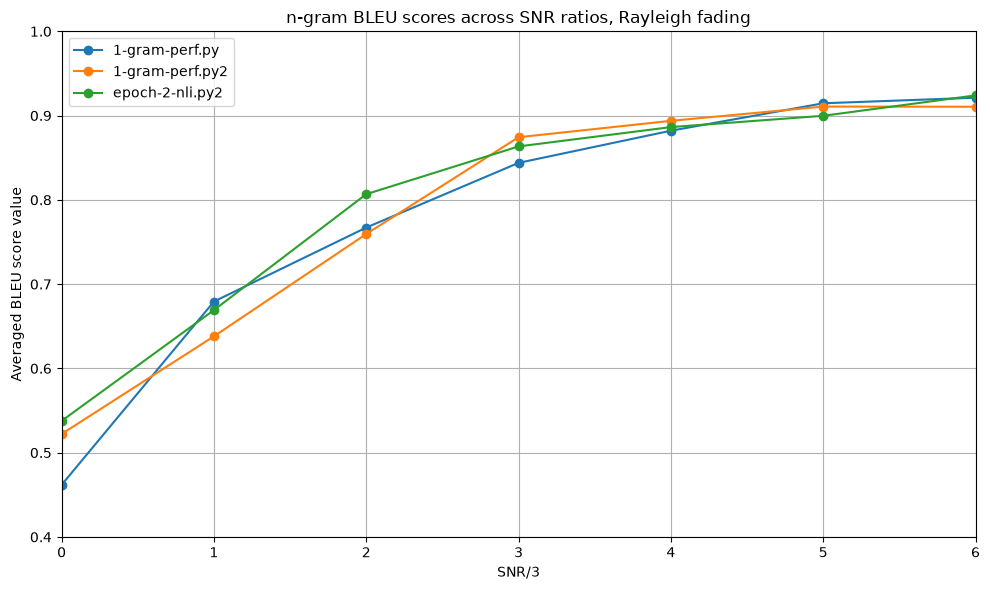

In [10]:
plt.figure(figsize=(10, 6))

for label, row in avg_df.iterrows():
    plt.plot(row.values, marker="o", label=str(label))

plt.xlabel("SNR/3")
plt.ylabel("Averaged BLEU score value")
plt.title("n-gram BLEU scores across SNR ratios, Rayleigh fading")
plt.legend()
plt.grid(True)
plt.ylim(0.4,1.0)
plt.xlim(0.0,6.0)

plt.tight_layout()
plt.show()

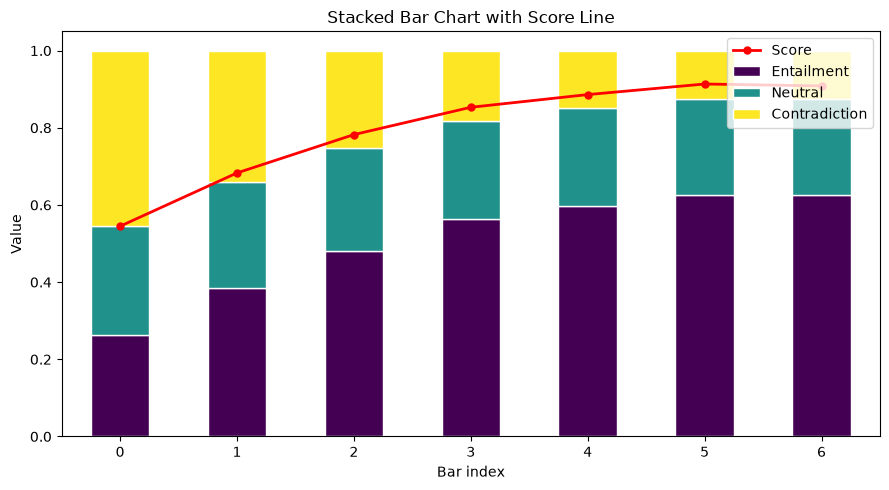

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = np.array([
    [0.26325175, 0.2823871,  0.45436093],
    [0.38554433, 0.2751392,  0.3393176 ],
    [0.48117274, 0.2669115,  0.2519151 ],
    [0.5626483,  0.25496408, 0.1823868 ],
    [0.59716606, 0.25497738, 0.1478558 ],
    [0.6267078,  0.24848473, 0.12480779],
    [0.6251832,  0.24954957, 0.12526579]
])

line_data = np.array([0.54491732, 0.68303692, 0.78238263, 0.85315084, 0.88607332, 0.91349744, 0.90858325])

df = pd.DataFrame(data, columns=['Entailment', 'Neutral', 'Contradiction'])

# Capture the axes object pandas returns
ax = df.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='viridis', edgecolor='white')

# Plot the line on the same axes
# x positions must align with bar positions (0, 1, 2, ...)
ax.plot(range(len(line_data)), line_data, color='red', marker='o', linewidth=2, markersize=5, label='BLEU Score')

ax.set_xlabel('SNR/3(db)')
ax.set_ylabel('Value')
ax.set_title('NLI and BLEU scores, 2 Epochs')
ax.set_xticklabels(range(len(df)), rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()